Plot study area map and Salish Sea Atlantis model polygons

In [165]:
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from shapely.affinity import rotate
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy import crs, feature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [102]:
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]

map_angle = -37

geom = data_df.unary_union
centroid = geom.centroid
ssam_rotated = data_df.copy()
ssam_rotated["geometry"] = data_df.geometry.apply(
    lambda g: rotate(g, map_angle, origin=geom.centroid)
    
)

land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[ssam_rotated.Region=='Juan de Fuca']
hs_df = data_df.loc[ssam_rotated.Region=='Howe Sound']
strait_df = data_df.loc[ssam_rotated.Region=='Strait of Georgia']
ps_df = data_df.loc[ssam_rotated.Region=='Puget Sound']

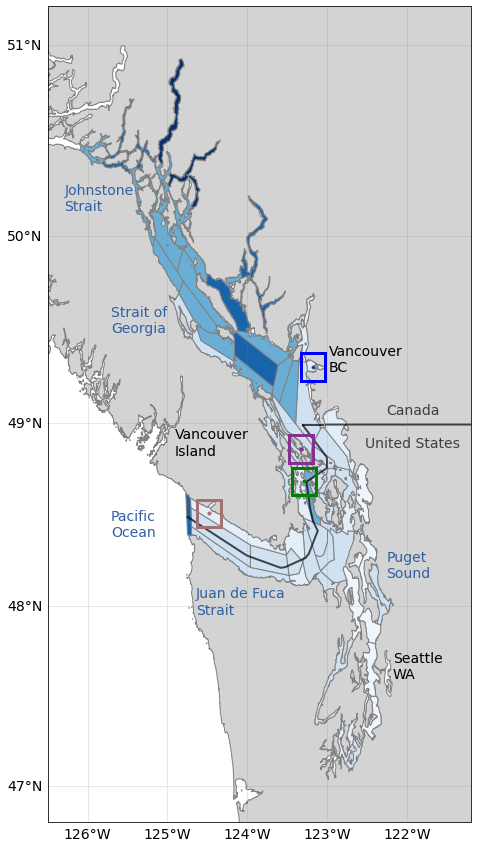

In [177]:
# Read shapefile
gdf = gpd.read_file(shapefile_name)

# Make sure the GeoDataFrame is in WGS84 (or convert it)
gdf = gdf.to_crs(epsg=4326)

# Create Mercator map
fig = plt.figure(figsize=(12, 15))
#fig.add_subplot()
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax,cax=cax, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
ax.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7)
ax.text(0.15, 0.35, 'Pacific\nOcean', transform=ax.transAxes,color='#2F61A4')
ax.text(0.80, 0.30, 'Puget\nSound', transform=ax.transAxes,color='#2F61A4')
ax.text(0.35, 0.255, 'Juan de Fuca\nStrait', transform=ax.transAxes,color='#2F61A4')
ax.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax.text(0.8, 0.5, 'Canada', transform=ax.transAxes,color='k',alpha=0.7)
ax.text(0.75, 0.46, 'United States', transform=ax.transAxes,color='k',alpha=0.7)
ax.text(0.15, 0.60, 'Strait of\nGeorgia', transform=ax.transAxes, color='#2F61A4') #,weight='bold'
ax.text(0.3, 0.45, 'Vancouver\nIsland', transform=ax.transAxes, color='k') #,weight='bold'
ax.text(-123.128392+0.15, 49.280076,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax.text(0.04, 0.75, 'Johnstone\nStrait', transform=ax.transAxes, color='#2F61A4')

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103

# Add box insets
width = 0.3
height = 0.15
line_width = 3

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='green',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax.add_patch(Active_Pass)
ax.add_patch(Turn_Point)
ax.add_patch(English_Bay)
ax.add_patch(Jstrait)

# Add box labels
#ax.text(APlon-1,APlat,"Active Pass",transform=ccrs.PlateCarree(),fontsize=13,color='#863092',weight='bold')
#ax.text(APlon-1,APlat,"Active Pass",transform=ccrs.PlateCarree(),fontsize=13,color='#863092',weight='bold')

# Add spill points
marker_size = 3


ax.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

#fig.add_subplot()

gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')

# Only label left and bottom axes
gl.top_labels = False
gl.right_labels = False

# Specify tick locations
#gl.xlocator = mticker.FixedLocator([-126, -125, -124, -123, -122])
#gl.ylocator = mticker.FixedLocator([47, 48, 49, 50, 51])

# Format as longitude/latitude
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
plt.show()

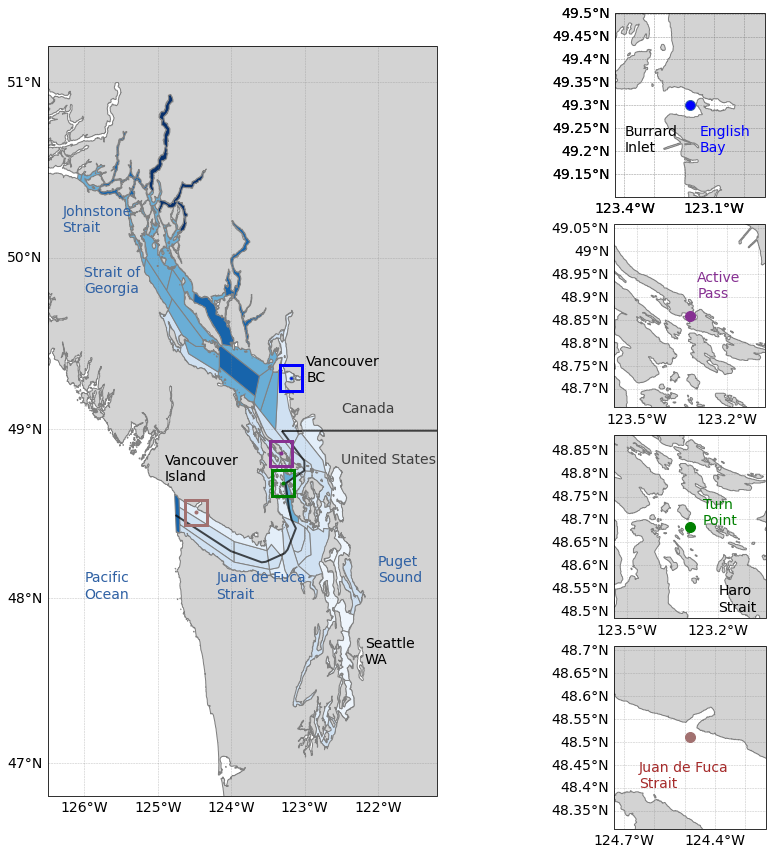

In [220]:
proj = ccrs.Mercator()

fig = plt.figure(figsize=(15, 15), constrained_layout=True )

# 4 rows, 5 columns
gs = plt.GridSpec(nrows=4,ncols=2,width_ratios=[1, 1], height_ratios=[1,1,1,1],
    wspace=0.15, hspace=0.15)

# Make sure the GeoDataFrame is in WGS84 (or convert it)
gdf = gdf.to_crs(epsg=4326)

# Create Mercator map
ax_main = fig.add_subplot(gs[:, 0], projection=proj)
# Four small maps in the last column
ax1 = fig.add_subplot(gs[0, 1], projection=proj)
ax2 = fig.add_subplot(gs[1, 1], projection=proj)
ax3 = fig.add_subplot(gs[2, 1], projection=proj)
ax4 = fig.add_subplot(gs[3, 1], projection=proj)

#ax = plt.axes(projection=ccrs.Mercator())

ax_main.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax_main, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
ax_main.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax_main.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7)
ax_main.text(-126, 48, 'Pacific\nOcean', transform=ccrs.PlateCarree(),color='#2F61A4')
ax_main.text(-122, 48.1, 'Puget\nSound', transform=ccrs.PlateCarree(),color='#2F61A4')
ax_main.text(-124.2, 48, 'Juan de Fuca\nStrait', transform=ccrs.PlateCarree(),color='#2F61A4')
ax_main.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax_main.text(-122.5, 49.1, 'Canada', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-122.5, 48.8, 'United States', transform=ccrs.PlateCarree(),color='k',alpha=0.7)
ax_main.text(-126, 49.8, 'Strait of\nGeorgia', transform=ccrs.PlateCarree(), color='#2F61A4') #,weight='bold'
ax_main.text(-124.9, 48.7, 'Vancouver\nIsland', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax_main.text(-123.128392+0.15, 49.280076,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax_main.text(-126.3, 50.15, 'Johnstone\nStrait', transform=ccrs.PlateCarree(), color='#2F61A4')

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103

# Add box insets
width = 0.3
height = 0.15
line_width = 3

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='green',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax_main.add_patch(Active_Pass)
ax_main.add_patch(Turn_Point)
ax_main.add_patch(English_Bay)
ax_main.add_patch(Jstrait)

# Add spill points
marker_size = 3

ax_main.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax_main.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

#side plots
width = 0.5
height = 0.4
marker_size = 10
ax1.set_extent([EBlon-width/2, EBlon+width/2, EBlat-height/2, EBlat+height/2],crs=ccrs.PlateCarree())
ax1.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax1.text(-123.4, 49.2,'Burrard\nInlet', transform=ccrs.PlateCarree(), color='k')
ax1.text(-123.15, 49.2,'English\nBay', transform=ccrs.PlateCarree(), color='blue')

ax2.set_extent([APlon-width/2, APlon+width/2, APlat-height/2, APlat+height/2],crs=ccrs.PlateCarree())
ax2.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax2.text(-123.3, 48.9,'Active\nPass', transform=ccrs.PlateCarree(), color='#863092')
ax2.annotate('Active\nPass',xy=(APlon, APlat),xytext=(APlon+1, APlat), fontsize=14,
    arrowprops=dict(facecolor='#863092'),verticalalignment='top',horizontalalignment='center')

ax3.set_extent([TPlon-width/2, TPlon+width/2, TPlat-height/2, TPlat+height/2],crs=ccrs.PlateCarree())
ax3.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax3.text(-123.25, 48.69,'Turn\nPoint', transform=ccrs.PlateCarree(), color='green')
ax3.text(-123.2, 48.5,'Haro\nStrait', transform=ccrs.PlateCarree(), color='k')

ax4.set_extent([JFlon-width/2, JFlon+width/2, JFlat-height/2, JFlat+height/2],crs=ccrs.PlateCarree())
ax4.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)
ax4.text(-124.65, 48.4,'Juan de Fuca\nStrait', transform=ccrs.PlateCarree(), color='brown') ##A27170

for ax in [ax_main, ax1, ax1, ax2, ax3, ax4]:
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

for ax in [ax1, ax2, ax3, ax4]:
    ax.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
    #ax.coastlines(resolution='10m')
    
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 15))

# 4 rows, 5 columns
gs = plt.GridSpec(nrows=4,ncols=1,width_ratios=[1],
    wspace=0.15, hspace=0.15)

gdf = gdf.to_crs(epsg=4326)

ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax2 = fig.add_subplot(gs[1, 0], projection=proj)
ax3 = fig.add_subplot(gs[2, 0], projection=proj)
ax4 = fig.add_subplot(gs[3, 0], projection=proj)

for ax in [ax1, ax1, ax2, ax3]:
    )
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='gray', alpha=0.5,linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    #ax.coastlines(resolution='10m')
#ax = plt.axes(projection=ccrs.Mercator())

ax_main.set_extent([-126.5, -121.2, 46.8, 51.2],crs=ccrs.PlateCarree())
# Plot shapefile
gdf.plot(column='BOTZ',
    ax=ax_main, cmap=cm.Blues, vmax=500,
    transform=ccrs.PlateCarree(), 
    facecolor='#EBEBEB',edgecolor='grey', 
    #legend=True, legend_kwds={'label': 'Box Depth (m)', "orientation": "horizontal"}, 
)

# Add text labels
ax_main.add_feature(feature.GSHHSFeature('full', edgecolor='grey', facecolor='lightgrey'))
ax_main.add_feature(feature.BORDERS,edgecolor='black',linewidth=2,alpha=0.7
ax_main.text(0.15, 0.35, 'Pacific\nOcean', transform=ax.transAxes,color='#2F61A4')
ax_main.text(0.80, 0.30, 'Puget\nSound', transform=ax.transAxes,color='#2F61A4')
ax_main.text(0.35, 0.255, 'Juan de Fuca\nStrait', transform=ax.transAxes,color='#2F61A4')
ax_main.text(-122.331030+0.15, 47.603895, 'Seattle\nWA', transform=ccrs.PlateCarree(),color='k')  
ax_main.text(0.8, 0.5, 'Canada', transform=ax.transAxes,color='k',alpha=0.7)
ax_main.text(0.75, 0.46, 'United States', transform=ax.transAxes,color='k',alpha=0.7)
ax_main.text(0.15, 0.60, 'Strait of\nGeorgia', transform=ax.transAxes, color='#2F61A4') #,weight='bold'
ax_main.text(0.3, 0.45, 'Vancouver\nIsland', transform=ax.transAxes, color='k') #,weight='bold'
ax_main.text(-123.128392+0.15, 49.280076,'Vancouver\nBC', transform=ccrs.PlateCarree(), color='k') #,weight='bold'
ax_main.text(0.04, 0.75, 'Johnstone\nStrait', transform=ax.transAxes, color='#2F61A4')

#Spill coordinates
APlon, APlat = -123.3239, 48.8594
TPlon, TPlat = -123.293519444444, 48.6843916666667
EBlon, EBlat = -123.181433333333,49.3002972222222
JFlon, JFlat = -124.4823,48.5103


line_width = 3

Active_Pass = Rectangle((APlon-width/2,APlat-height/2),width,height,facecolor='none',edgecolor='#863092',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Turn_Point = Rectangle((TPlon-width/2,TPlat-height/2),width,height,facecolor='none',edgecolor='green',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
English_Bay = Rectangle((EBlon-width/2,EBlat-height/2),width,height,facecolor='none',edgecolor='blue',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)
Jstrait = Rectangle((JFlon-width/2,JFlat-height/2),width,height,facecolor='none',edgecolor='#A27170',linewidth=line_width,transform=ccrs.PlateCarree(),zorder=10)

ax_main.add_patch(Active_Pass)
ax_main.add_patch(Turn_Point)
ax_main.add_patch(English_Bay)
ax_main.add_patch(Jstrait)

# Add spill points
# Add box insets
width = 0.5
height = 0.2
marker_size = 3

ax_main.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E
ax_main.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)
ax_main.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

ax1.set_extent([EBlon-width/2, EBlon+width/2, EBlat-height/2, EBlat+height/2],crs=ccrs.PlateCarree())
ax1.plot(EBlon, EBlat, marker='o', markersize=marker_size, color='blue', markeredgecolor='#2F61A4', transform=ccrs.PlateCarree(), zorder=10)

ax2.set_extent([APlon-width/2, APlon+width/2, APlat-height/2, APlat+height/2],crs=ccrs.PlateCarree())
ax2.plot(APlon, APlat, marker='o', markersize=marker_size, color='#863092', markeredgecolor='#863092', transform=ccrs.PlateCarree(), zorder=10)

ax3.set_extent([TPlon-width/2, TPlon+width/2, TPlat-height/2, TPlat+height/2],crs=ccrs.PlateCarree())
ax3.plot(TPlon, TPlat, marker='o', markersize=marker_size, color='green', markeredgecolor='green', transform=ccrs.PlateCarree(), zorder=10) ##6DB48E

ax4.set_extent([JFlon-width/2, JFlon+width/2, JFlat-height/2, JFlat+height/2],crs=ccrs.PlateCarree())
ax4.plot(JFlon, JFlat, marker='o', markersize=marker_size, color='#A27170', markeredgecolor='#A27170', transform=ccrs.PlateCarree(), zorder=10)

plt.show()

ValueError: Image size of 155372x138731 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 720x864 with 5 Axes>